In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
df=pd.read_csv('dataset_reducido.csv')

In [6]:
print("informacion del dataset")
df.info()

informacion del dataset
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   protocol_type  10000 non-null  str  
 1   service        10000 non-null  str  
 2   duration       10000 non-null  int64
 3   src_bytes      10000 non-null  int64
 4   dst_bytes      10000 non-null  int64
 5   logged_in      10000 non-null  int64
 6   count          10000 non-null  int64
 7   target         10000 non-null  str  
dtypes: int64(5), str(3)
memory usage: 767.1 KB


In [7]:
print('valores nulos')
print(df.isnull().sum())

valores nulos
protocol_type    0
service          0
duration         0
src_bytes        0
dst_bytes        0
logged_in        0
count            0
target           0
dtype: int64


C:\Users\IPF-2026\AppData\Local\Temp\ipykernel_19748\3144578369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='viridis')


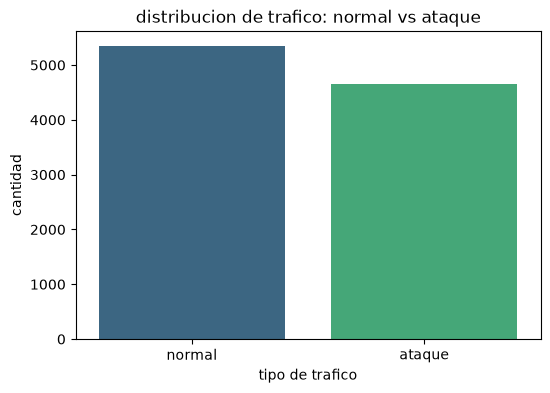

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='target', palette='viridis')
plt.title('distribucion de trafico: normal vs ataque')
plt.xlabel('tipo de trafico')
plt.ylabel('cantidad')
plt.show()

In [9]:
display(df.describe())

,duration,src_bytes,dst_bytes,logged_in,count
count,10000.00000,1.000000e+04,1.000000e+04,10000.000000,10000.000000
mean,303.57040,1.111772e+04,2.878036e+03,0.394100,83.973800
std,2625.60665,2.581551e+05,7.440287e+04,0.488681,115.237395
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,2.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,14.000000
75%,0.00000,2.680000e+02,4.640000e+02,1.000000,141.000000
max,42492.00000,1.882898e+07,5.153771e+06,1.000000,511.000000


In [10]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Separar las características (X) de la variable objetivo (y)
X = df.drop('target', axis=1)
y = df['target']

# 2. Codificar la variable objetivo (Label Encoding)
# Convierte 'normal' en 0 y 'ataque' en 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Codificar variables categóricas (One-Hot Encoding)
# Convierte 'protocol_type' y 'service' en múltiples columnas de 0 y 1
X_encoded = pd.get_dummies(X, columns=['protocol_type', 'service'], dtype=int)

# 4. Escalar las variables numéricas (Estandarización)
# Evita que variables con números gigantes (como src_bytes) opaquen a otras pequeñas (como count)
scaler = StandardScaler()

# Seleccionamos solo las variables numéricas continuas a escalar
# Nota: 'logged_in' ya es 0 o 1, no hace falta escalarla.
columnas_numericas = ['duration', 'src_bytes', 'dst_bytes', 'count']

# Aplicamos el escalado solo a esas columnas
X_encoded[columnas_numericas] = scaler.fit_transform(X_encoded[columnas_numericas])

print(" Dimensiones después del preprocesamiento ")
print(f"X (Características): {X_encoded.shape}")
print(f"y (Objetivo): {y_encoded.shape}")

# Ver cómo quedó el dataset final listo para la IA
display(X_encoded.head())

 Dimensiones después del preprocesamiento 
X (Características): (10000, 71)
y (Objetivo): (10000,)


,duration,src_bytes,dst_bytes,logged_in,count,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,...,service_systat,service_telnet,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois
0,-0.115625,-0.042929,-0.038684,0,-0.711383,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,-0.115625,-0.043068,-0.038684,0,-0.364256,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-0.115625,-0.043068,-0.038684,0,1.735862,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-0.115625,-0.043068,-0.038684,0,0.225860,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-0.115625,-0.043068,-0.038684,0,-0.720061,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


--- Evaluación del Modelo ---
Precisión General (Accuracy): 0.9935

Reporte de Clasificación:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      0.99       913
  Ataque (1)       0.99      1.00      0.99      1087

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



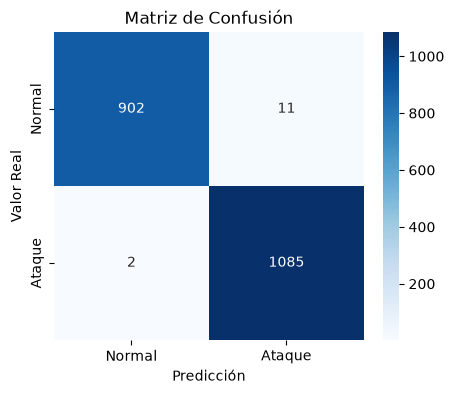


¡Exportación exitosa! Archivo guardado en 'models/modelo_completo.pkl'


In [11]:
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dividir en datos de Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

# 2. Inicializar y Entrenar el modelo (Random Forest es ideal para estos datos)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# 3. Evaluar el modelo con los datos de prueba
y_pred = modelo_rf.predict(X_test)

print("--- Evaluación del Modelo ---")
print(f"Precisión General (Accuracy): {accuracy_score(y_test, y_pred):.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Ataque (1)']))

# Matriz de Confusión (Opcional pero suma muchos puntos visualizarla)
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Ataque'], yticklabels=['Normal', 'Ataque'])
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

# 4. Crear la carpeta 'models/' que exige la consigna y exportar
os.makedirs('models', exist_ok=True)

# TRUCO PROFESIONAL: Guardamos el modelo, el scaler y las columnas en un solo archivo
# Esto es vital porque la API (Backend) necesitará saber exactamente cómo transformar
# los 7 inputs del usuario en estas 71 columnas antes de predecir.
artefactos = {
    'modelo': modelo_rf,
    'scaler': scaler,
    'columnas': X_encoded.columns
}

joblib.dump(artefactos, 'models/modelo_completo.pkl')
print("\n¡Exportación exitosa! Archivo guardado en 'models/modelo_completo.pkl'")